# BioPlex Compartment Organization Project — Stage 2

**Goal of this notebook:** for each cell line (HEK293T, HCT116), build the compartment x
compartment "mixing matrix" -- how often pairs of compartments interact vs. how often a
degree-matched random network would predict -- and turn that into per-pair significance plus a
single global summary statistic (mutual information).

**Inputs** (from Stages 0-1, saved in `data/stage0_1` and loaded fresh so this notebook is self-contained):
- `bioplex_hek293t_edges.csv`, `bioplex_hct116_edges.csv`
- `protein_compartments.csv`

**Outputs** (saved to `./data/stage2`):
- `mixing_matrix_{cell_line}.csv` — raw observed compartment x compartment edge counts
- `mixing_zscores_{cell_line}.csv` — per-pair z-scores + FDR-corrected significance
- `mixing_summary_{cell_line}.json` — total edges used, mutual information (bits)

**As with the earlier notebook, I couldn't run this end-to-end myself** (no network access in my
environment) -- the double-edge-swap null model in particular is worth watching closely on first
run, since it's the one piece here doing real statistical work rather than bookkeeping.

## 2.0 Setup and load Stage 0/1 outputs

In [40]:
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations_with_replacement

INPUT_DIR = Path("data/stage0_1")   # Stage 0/1 outputs (edge lists, protein_compartments.csv)
OUTPUT_DIR = Path("data/stage2")    # this notebook's own outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 0
rng = np.random.default_rng(RNG_SEED)

pd.set_option("display.max_columns", 20)

In [41]:
def load_graph(edge_csv: str) -> nx.Graph:
    """Load an undirected graph from a Stage 0/1 edge CSV.

    The CSV can still contain a handful of duplicate/reverse-direction rows for the same
    pair (Stage 0/1 saves the raw filtered dataframe, not the deduplicated graph) -- this
    keeps the max pInt when that happens, matching Stage 0/1's build_graph convention.

    Parameters:
        edge_csv (str): filename of the edge-list CSV to load, relative to INPUT_DIR. Must
            have UniprotA, UniprotB, and pInt columns.

    Returns:
        (nx.Graph): undirected graph with one edge per distinct protein pair, each edge
            carrying a `pInt` attribute (the max of any duplicate/reverse-direction rows for
            that pair).
    """
    df = pd.read_csv(INPUT_DIR / edge_csv)
    G = nx.Graph()
    for _, row in df.iterrows():
        u, v, p = row["UniprotA"], row["UniprotB"], row["pInt"]
        if G.has_edge(u, v):
            G[u][v]["pInt"] = max(G[u][v]["pInt"], p)
        else:
            G.add_edge(u, v, pInt=p)
    return G

G_hek293t = load_graph("bioplex_hek293t_edges.csv")
G_hct116 = load_graph("bioplex_hct116_edges.csv")
print(f"293T:   {G_hek293t.number_of_nodes():,} nodes, {G_hek293t.number_of_edges():,} edges")
print(f"HCT116: {G_hct116.number_of_nodes():,} nodes, {G_hct116.number_of_edges():,} edges")

293T:   13,689 nodes, 115,868 edges
HCT116: 10,024 nodes, 70,421 edges


In [42]:
protein_compartments = pd.read_csv(INPUT_DIR / "protein_compartments.csv")
protein_compartments["compartments"] = protein_compartments["compartments"].str.split(";")

# Stage 2 only uses the single-compartment subset -- multi-compartment proteins
# are held out for Stage 3 (mediator/participation-coefficient analysis).
single_compartment = protein_compartments[protein_compartments["n_compartments"] == 1].copy()
single_compartment["compartment"] = single_compartment["compartments"].apply(lambda x: x[0])

# uniprot -> compartment lookup, used to label graph nodes
single_compartment_map = dict(zip(single_compartment["uniprot"], single_compartment["compartment"]))
print(f"{len(single_compartment_map):,} proteins carry a single, confident, specific-tier compartment label.")
print(single_compartment["compartment"].value_counts())

4,515 proteins carry a single, confident, specific-tier compartment label.
compartment
nucleus                  2034
plasma_membrane           804
mitochondrion             519
cytosol                   423
extracellular             374
golgi                     132
cytoskeleton              112
endoplasmic_reticulum      53
vesicle                    25
lysosome                   18
cell junction              13
peroxisome                  8
Name: count, dtype: int64


## 2.1 Build the induced subgraph

We restrict to the induced subgraph on single-compartment-labeled proteins: keep a node only if
it has a label, and keep an edge only if *both* endpoints have one. This means a labeled
protein's degree *within this analysis* will generally be lower than its true total degree in the
full network -- edges to unlabeled or multi-compartment partners are dropped here (not lost
forever; multi-compartment proteins are exactly what Stage 3 is built around).

Both `G_hek293t` and `G_hct116` go through the identical function below, which also stamps each node
with a `compartment` attribute so downstream code never has to look it up separately.

In [43]:
def build_induced_subgraph(G: nx.Graph, compartment_map: dict) -> nx.Graph:
    """Restrict a graph to the induced subgraph on nodes present in `compartment_map`, and
    stamp each retained node with its compartment label.

    A node is kept only if it has a label; an edge is kept only if both endpoints have one.

    Parameters:
        G (nx.Graph): the full interaction graph to restrict.
        compartment_map (dict): mapping from node (UniProt accession) to its coarse
            compartment label.

    Returns:
        (nx.Graph): the induced subgraph on labeled nodes, with a `compartment` node
            attribute set on every node.
    """
    labeled_nodes = [node for node in G.nodes if node in compartment_map]
    G_sub = G.subgraph(labeled_nodes).copy()
    nx.set_node_attributes(G_sub, {node: compartment_map[node] for node in G_sub.nodes}, name="compartment")
    return G_sub

G_hek293t_sub = build_induced_subgraph(G_hek293t, single_compartment_map)
G_hct116_sub = build_induced_subgraph(G_hct116, single_compartment_map)

for name, G_full, G_sub in [("293T", G_hek293t, G_hek293t_sub), ("HCT116", G_hct116, G_hct116_sub)]:
    print(f"{name}: {G_sub.number_of_nodes():,}" + "/" + f"{G_full.number_of_nodes():,} nodes labeled "
          f"({G_sub.number_of_nodes() / G_full.number_of_nodes():.1%}), "
          f"{G_sub.number_of_edges():,}" + "/" + f"{G_full.number_of_edges():,} edges retained "
          f"({G_sub.number_of_edges() / G_full.number_of_edges():.1%})")

293T: 4,023/13,689 nodes labeled (29.4%), 9,586/115,868 edges retained (8.3%)
HCT116: 2,721/10,024 nodes labeled (27.1%), 5,775/70,421 edges retained (8.2%)


## 2.2 Observed mixing matrix

**Counting convention** (matters for everything downstream, so it's worth being explicit): each
edge is counted exactly **once**, into a single canonical cell keyed by the *sorted* pair of
compartments -- e.g. an ER-mitochondrion edge always increments the `(endoplasmic_reticulum,
mitochondrion)` cell, never a separate `(mitochondrion, endoplasmic_reticulum)` cell. This is
simpler than Newman's fractional convention (which splits each cross-compartment edge's weight
across two symmetric matrix entries) and is fine here, since the *only* thing this matrix is used
for in 2.3-2.4 is a straight comparison against a null built with the identical counting rule. We
switch to the properly normalized symmetric form only in 2.6, where the convention actually
matters (mutual information).

In [44]:
def compute_mixing_counts(G: nx.Graph) -> pd.Series:
    """Count how many edges connect each pair of compartments, with each edge counted
    exactly once under a canonical (sorted) compartment-pair key.

    Parameters:
        G (nx.Graph): graph whose nodes carry a `compartment` attribute (see
            build_induced_subgraph).

    Returns:
        (pd.Series): edge counts indexed by canonical, sorted (compartment_a,
            compartment_b) tuples, sorted by index.
    """
    counts = {}
    for u, v in G.edges():
        pair = tuple(sorted((G.nodes[u]["compartment"], G.nodes[v]["compartment"])))
        counts[pair] = counts.get(pair, 0) + 1
    return pd.Series(counts, name="count").sort_index()


def mixing_counts_to_matrix(counts: pd.Series, compartments: list) -> pd.DataFrame:
    """Expand a canonical-pair count Series into a full, symmetric compartment x compartment
    DataFrame suitable for display or heatmaps.

    Parameters:
        counts (pd.Series): edge counts indexed by canonical (sorted) compartment-pair
            tuples, as returned by compute_mixing_counts.
        compartments (list): full list of compartment names to use as the matrix's
            row/column index, in the desired display order.

    Returns:
        (pd.DataFrame): symmetric compartment x compartment matrix of edge counts, indexed
            and columned by `compartments`.
    """
    M = pd.DataFrame(0, index=compartments, columns=compartments, dtype=int)
    for (a, b), n in counts.items():
        M.loc[a, b] = n
        M.loc[b, a] = n
    return M


compartments_list = sorted(single_compartment["compartment"].unique())

obs_counts_hek293t = compute_mixing_counts(G_hek293t_sub)
obs_matrix_hek293t = mixing_counts_to_matrix(obs_counts_hek293t, compartments_list)

print(f"Total edges in 293T induced subgraph: {obs_counts_hek293t.sum():,}")
obs_matrix_hek293t

Total edges in 293T induced subgraph: 9,586


,cell junction,cytoskeleton,cytosol,endoplasmic_reticulum,extracellular,golgi,lysosome,mitochondrion,nucleus,peroxisome,plasma_membrane,vesicle
cell junction,1,1,1,0,5,0,0,2,19,0,6,1
cytoskeleton,1,9,18,5,9,1,2,8,101,0,40,2
cytosol,1,18,90,13,83,25,5,109,475,1,170,4
endoplasmic_reticulum,0,5,13,5,46,10,2,16,55,0,40,0
extracellular,5,9,83,46,113,113,7,132,291,1,207,1
golgi,0,1,25,10,113,40,6,39,42,1,184,1
lysosome,0,2,5,2,7,6,1,2,12,0,12,0
mitochondrion,2,8,109,16,132,39,2,1121,717,0,390,4
nucleus,19,101,475,55,291,42,12,717,3553,3,536,8
peroxisome,0,0,1,0,1,1,0,0,3,0,4,1


## 2.3 Null model: Maslov-Sneppen rewiring

**The algorithm.** This Markov-Chain Monte-Carlo method generates a compartment-blind null model via degree-preserving double-edge-swap randomization. Pick two edges A-B and C-D at random. Propose rewiring them to A-D and C-B.
Accept the swap only if it's legal (no self-loops: A != D and C != B; and A-D, C-B don't already
exist -- otherwise we'd collapse two edges into one and silently lose one). Repeat many times.

**Why this preserves degree exactly:** A had some number of edges before the swap and the same
number after -- it traded partner B for partner D, but its *count* of partners never changes.
This holds for every node, every swap. So after any number of swaps, every node's degree is
bit-for-bit identical to the original graph -- only *who* each node connects to has been
scrambled.

**Why this is the right null:** it isolates the one thing we actually want to ask about --
whether compartment identity predicts connection pattern -- from the one thing we don't want
contaminating the answer -- how many partners each protein happens to have overall. A hub protein
stays a hub (same degree) in every shuffled version; it just gets reassigned to random partners
each time. Whatever mixing signal survives this can't be explained by "some compartments just
have more highly-connected proteins."

**Crucially, the swap is compartment-blind.** `double_edge_swap` operates purely on the anonymous
edge list; it has no notion of compartment at all. We do NOT restrict swaps to stay within a
compartment pair -- doing so would preserve the very structure we're trying to test against by
construction, which would make the null trivially match the real data.

**Sampling strategy (this is a Markov chain, not independent restarts).** We do not rebuild a
fresh random graph from scratch for every sample -- that would be correct but wasteful. Instead
we do one long chain of swaps on a single working copy, and only record a "sample" (recompute the
mixing matrix) every `SWAPS_PER_SAMPLE` swaps, discarding a `BURN_IN` batch of swaps up front.
This is standard Monte Carlo Markov Chain practice: consecutive graph states one swap apart are
almost identical (barely informative as *independent* samples), so we let the chain run for a
while between samples to decorrelate them.

**Choosing the three constants below.**

- `N_NULL_SAMPLES` sets the finest possible empirical p-value to ~1/N_NULL_SAMPLES (500 -> 0.002).
  That needs enough headroom to survive BH-FDR correction across all ~78 compartment pairs tested
  at once (section 2.4) -- too few samples and even the most extreme pairs get rounded to the same
  p-value and lose resolution after correction. 500 is a practical middle ground: fine enough for
  this many simultaneous comparisons without making the swap budget below (which scales linearly
  with `N_NULL_SAMPLES`) unaffordable.
- `BURN_IN_MULTIPLIER` is a one-time swap budget (as a multiple of `n_edges`) spent up front so the
  chain fully "forgets" the real graph's mixing structure before we start recording -- that
  structure is exactly what we're testing against, so any of it surviving into the null would bias
  every z-score toward zero. Degree-preserving double-edge-swap chains are conventionally
  considered well-mixed after on the order of a few x `n_edges` swaps; 10x is a
  conservative-but-affordable choice at this graph's size (~5-10k edges post-2.1
  induced-subgraph restriction).
- `SWAPS_PER_SAMPLE_MULTIPLIER` is a swap budget (as a multiple of `n_edges`) spent between each
  recorded sample, to decorrelate it from the previous one. Deliberately smaller than
  `BURN_IN_MULTIPLIER` -- burn-in has to escape the *real* graph's structure (a large
  displacement), while inter-sample spacing only has to decorrelate from an *already-randomized*
  previous sample, which needs less distance. `safe_swap` (below) retries the remaining budget
  across individual batch failures rather than giving up on the whole call the moment one batch
  hits `max_tries`, and section 2.3b plots and prints exactly how much of the burn-in and
  per-sample budgets were actually completed -- check there before trusting `null_std` at face
  value, rather than guessing from how often this paragraph's old assumption might have been
  violated.

In [45]:
N_NULL_SAMPLES = 500                # number of null mixing matrices to generate
BURN_IN_MULTIPLIER = 10            # burn-in swaps = this * n_edges
SWAPS_PER_SAMPLE_MULTIPLIER = 2    # swaps between samples = this * n_edges
SWAP_BATCH_SIZE = 100               # swaps attempted per nx.double_edge_swap() call
MAX_CONSECUTIVE_BATCH_FAILURES = 5  # give up only once the graph looks structurally stuck,
                                     # not after a single unlucky batch

def format_duration(seconds: float) -> str:
    """Format a duration in seconds as "Hh Mm" (or just "Mm" under an hour), for the
    elapsed/ETA progress lines below -- sampling runs can take long enough that a raw minute
    count stops being easy to read at a glance.

    Parameters:
        seconds (float): duration in seconds.

    Returns:
        (str): human-readable duration, e.g. "1h 23m" or "47m".
    """
    total_minutes = int(seconds // 60)
    hours, minutes = divmod(total_minutes, 60)
    return f"{hours}h {minutes}m" if hours else f"{minutes}m"

def double_edge_swap_chain(G: nx.Graph, n_samples: int, burn_in_mult: int,
                            per_sample_mult: int, seed: int = 0):
    """Run a single degree-preserving double-edge-swap Markov chain over `G` and yield a
    (null mixing-count Series, diagnostics dict) pair after each recorded sample.

    Node compartment labels are untouched by the swaps themselves -- only edge endpoints are
    scrambled.

    Parameters:
        G (nx.Graph): graph to randomize; not modified in place (a working copy is made
            internally).
        n_samples (int): number of null samples to yield.
        burn_in_mult (int): burn-in swap budget, as a multiple of `G`'s edge count, run once
            before the first recorded sample.
        per_sample_mult (int): swap budget, as a multiple of `G`'s edge count, run between
            each recorded sample.
        seed (int): seed for the internal random number generator. Defaults to 0.

    Yields:
        (pd.Series, dict): a mixing-count Series (as returned by compute_mixing_counts) for
            each of the `n_samples` post-burn-in chain states, paired with the safe_swap
            diagnostics dict for the swap budget that produced it. The first yielded
            diagnostics dict additionally carries a "burn_in" key holding the burn-in phase's
            own diagnostics, since burn-in has no sample of its own to attach to -- see
            section 2.3b for how both get consumed.
    """
    G_work = G.copy()
    n_edges = G_work.number_of_edges()
    burn_in = burn_in_mult * n_edges
    per_sample = per_sample_mult * n_edges
    original_edges = {frozenset(e) for e in G_work.edges()}

    # Draw a large unrelated number (for sampling portion)
    rng_local = np.random.default_rng(seed)
    seed_seq = int(rng_local.integers(0, 2**32 - 1))

    def safe_swap(n_target_swaps, seed_val, track_overlap=False):
        """Perform `n_target_swaps` double-edge-swaps on the enclosing `G_work`, in a
        batched loop rather than trusting a single nx.double_edge_swap call to hit the exact
        target (it can silently undershoot if `max_tries` is exhausted on a hard graph).

        A failed batch no longer aborts the whole call. nx.double_edge_swap mutates G_work
        in place as it goes, so any swaps completed before it raises are never undone -- the
        only thing a failure used to cost was the *remaining*, not-yet-attempted budget,
        since the old code `break`-ed out of this entire loop on the first failure. Now it
        just moves on to a fresh batch (with its own seed, so a retry doesn't replay an
        identical failing draw), and only gives up early if
        `MAX_CONSECUTIVE_BATCH_FAILURES` batches fail back-to-back -- evidence the graph is
        genuinely out of legal swaps right now, not just unlucky once.

        Parameters:
            n_target_swaps (int): total number of successful swaps to attempt.
            seed_val (int): base seed for this call; batch attempt k uses seed_val + k.
            track_overlap (bool): if True, record the fraction of edges still identical to
                the original graph after every batch attempt (used for the burn-in
                convergence plot in 2.3b). Left off for the per-sample gaps by default, since
                it isn't needed there and would otherwise be recomputed ~n_samples times for
                no benefit.

        Returns:
            (dict): diagnostics with keys "target" (n_target_swaps), "done" (swaps actually
                completed -- may be less than target, see above), "n_batches_failed" (count
                of batches that hit NetworkXAlgorithmError), and "overlap_trace" (list of
                (cumulative_swaps_done, fraction_of_original_edges_unchanged) checkpoints,
                one per successful batch, empty unless track_overlap=True).
        """
        done = 0
        n_batches_failed = 0
        consecutive_failures = 0
        overlap_trace = []
        attempt = 0
        while done < n_target_swaps:
            batch = min(SWAP_BATCH_SIZE, n_target_swaps - done)
            attempt += 1
            try:
                nx.double_edge_swap(G_work, nswap=batch, max_tries=batch * 50,
                                     seed=seed_val + attempt)
                done += batch
                consecutive_failures = 0
            except nx.NetworkXAlgorithmError:
                n_batches_failed += 1
                consecutive_failures += 1
                if consecutive_failures >= MAX_CONSECUTIVE_BATCH_FAILURES:
                    break
                continue

            if track_overlap:
                current_edges = {frozenset(e) for e in G_work.edges()}
                overlap_trace.append((done, len(original_edges & current_edges) / len(original_edges)))

        return {"target": n_target_swaps, "done": done, "n_batches_failed": n_batches_failed,
                "overlap_trace": overlap_trace}

    # Burn in.
    burn_in_diagnostics = safe_swap(burn_in, seed_seq, track_overlap=True)

    # Sample.
    for i in range(n_samples):
        diagnostics = safe_swap(per_sample, seed_seq + i + 1)
        if i == 0:
            diagnostics["burn_in"] = burn_in_diagnostics
        yield compute_mixing_counts(G_work), diagnostics

## 2.3a Choosing `SWAPS_PER_SAMPLE_MULTIPLIER` without guessing: a decorrelation probe

Section 2.3b's autocorrelation panel can only test a multiplier we've already committed to, and
each test costs a full `N_NULL_SAMPLES`-sample run -- tens of minutes to well over an hour. We
tried 5x (failed), then 20x (failed at nearly the same magnitude, no visible improvement).
Continuing to guess and re-paying for a full run each time doesn't scale, and worse, that panel's
lag axis is measured in multiples of whatever spacing we already picked -- it literally cannot
see what's happening *between* those multiples, so it can't tell us how far off a fixed multiplier
is, only pass/fail on the one we tried.

**The probe below reuses `double_edge_swap_chain` completely unchanged** -- same burn-in, same
`safe_swap` machinery, same underlying Markov chain -- it just checkpoints the
same-compartment-edge-count statistic far more often (every `PROBE_CHECKPOINT_MULT * n_edges`
swaps, well below any candidate multiplier) instead of only at multiples of one guess. That turns
"how many swaps apart does correlation actually die out" into something we read off directly from
one run's autocorrelation-vs-real-swap-distance curve, rather than something we pay to test one
guess at a time. The probe's own trace is diagnostic only -- it is never used as a null
distribution, and the actual `SWAPS_PER_SAMPLE_MULTIPLIER` used for real sampling still spaces
samples widely, same as before, just now backed by a measured number instead of a guess.

At the default settings (`PROBE_CHECKPOINT_MULT=5`, `PROBE_N_CHECKPOINTS=300`), each probe run
covers swap distances out to 500x `n_edges` -- well past the 200x `n_edges` we already know 20x
wasn't enough for -- at roughly 5% of the swap budget the failed 20x/500-sample run just cost.
Expect this to take single-digit minutes per cell line, not tens.

In [46]:
# PROBE_CHECKPOINT_MULT = 5    # probe checkpoint spacing, as a multiple of n_edges -- stays well
#                               # below any SWAPS_PER_SAMPLE_MULTIPLIER under consideration
# PROBE_N_CHECKPOINTS = 1800   # covers swap distances out to PROBE_CHECKPOINT_MULT * PROBE_N_CHECKPOINTS
#                               # n_edges-multiples (reliable autocorrelation estimates only go out to
#                               # roughly a third of that -- see max_lag below). Bumped up from 300 after
#                               # HCT116's raw trace showed a slow decline followed by an abrupt jump
#                               # *past* its starting level rather than settling -- that overshoot looks
#                               # more like one large excursion of an already-stationary, very-slow-period
#                               # process than like ongoing non-equilibrium drift, but a 300-checkpoint
#                               # window (1500x n_edges) wasn't enough to tell whether it repeats (a real
#                               # long period -- SWAPS_PER_SAMPLE_MULTIPLIER needs to span at least one full
#                               # cycle) or was a one-off transient (in which case it's genuinely settled
#                               # from here on). This wider window should show either several repeats or a
#                               # clear flattening.

# def estimate_decorrelation_swaps(G: nx.Graph, checkpoint_mult: int = PROBE_CHECKPOINT_MULT,
#                                   n_checkpoints: int = PROBE_N_CHECKPOINTS, seed: int = 0,
#                                   label: str = "", progress_every: int = 50) -> dict:
#     """One-off diagnostic: run a single double-edge-swap chain -- via double_edge_swap_chain,
#     unchanged, so it gets the same burn-in and safe_swap retry behavior as a real sampling run
#     -- but checkpoint the same-compartment-edge-count statistic far more often than any
#     SWAPS_PER_SAMPLE_MULTIPLIER under consideration, to read off how many swaps are actually
#     needed between independent samples.

#     This probe is deliberately kept single-chain and sequential -- its whole point is to
#     measure autocorrelation along one continuous trajectory, which needs a single unbroken
#     chain.

#     Parameters:
#         G (nx.Graph): graph to probe; not modified in place.
#         checkpoint_mult (int): checkpoint spacing, as a multiple of n_edges. Defaults to
#             PROBE_CHECKPOINT_MULT.
#         n_checkpoints (int): number of checkpoints to record. Defaults to
#             PROBE_N_CHECKPOINTS.
#         seed (int): seed for the underlying chain. Defaults to 0.
#         label (str): tag for progress prints; pass "" to stay silent. Defaults to "".
#         progress_every (int): print an elapsed/ETA line every this many checkpoints (always
#             including the last one). Set to 0 to disable. Defaults to 50.

#     Returns:
#         (dict): {"n_edges", "checkpoint_mult", "trace" (pd.Series of the statistic at each
#             checkpoint), "autocorr" (pd.Series of autocorrelation, indexed by real swap-lag
#             rather than checkpoint-lag), "n_batches_failed" (total NetworkXAlgorithmError
#             count across every checkpoint -- a sanity check that a raw-trace jump isn't just
#             an artifact of a run of failed/undershot batches around that point)}.
#     """
#     n_edges = G.number_of_edges()
#     same_compartment_counts = []
#     n_batches_failed = 0
#     prefix = f"[{label}] " if label else ""

#     chain_start = time.monotonic()
#     checkpointing_start = None
#     for i, (null_counts, diagnostics) in enumerate(
#         double_edge_swap_chain(G, n_checkpoints, BURN_IN_MULTIPLIER, checkpoint_mult, seed=seed),
#         start=1,
#     ):
#         if "burn_in" in diagnostics:
#             print(f"{prefix}burn-in done ({time.monotonic() - chain_start:.0f}s) "
#                   f"-- starting {n_checkpoints} probe checkpoints")
#             checkpointing_start = time.monotonic()
#         same_compartment_counts.append(sum(c for pair, c in null_counts.items() if pair[0] == pair[1]))
#         n_batches_failed += diagnostics["n_batches_failed"]

#         if progress_every and (i % progress_every == 0 or i == n_checkpoints):
#             elapsed = time.monotonic() - checkpointing_start
#             eta = (elapsed / i) * (n_checkpoints - i)
#             print(f"{prefix}probe checkpoint {i}/{n_checkpoints} ({100 * i / n_checkpoints:.0f}%) -- "
#                   f"elapsed {format_duration(elapsed)}, ETA {format_duration(eta)}")

#     trace = pd.Series(same_compartment_counts)
#     checkpoint_swaps = checkpoint_mult * n_edges
#     max_lag = max(1, n_checkpoints // 3)  # keep estimates from getting too noisy near the tail
#     autocorr = pd.Series({k * checkpoint_swaps: trace.autocorr(lag=k) for k in range(1, max_lag + 1)})
#     return {"n_edges": n_edges, "checkpoint_mult": checkpoint_mult, "trace": trace,
#             "autocorr": autocorr, "n_batches_failed": n_batches_failed}


# def plot_decorrelation_probe(probe: dict, title_prefix: str, min_consecutive: int = 5):
#     """Plot a decorrelation probe's raw trace and autocorrelation-vs-swap-distance curve, and
#     print a recommended SWAPS_PER_SAMPLE_MULTIPLIER plus a trend-sanity-check.

#     The raw-trace panel exists because autocorrelation computed on a *non-stationary* (still
#     drifting) series is not interpretable as a decorrelation distance -- a smooth, sustained
#     trend in the underlying statistic mechanically produces an autocorrelation curve that
#     decays through zero into negative territory, mimicking long-range anti-correlation that
#     isn't really there. That shape means "the chain hadn't reached equilibrium yet," not "it
#     decorrelates slowly." Plotting the raw trace lets you see a real trend directly instead of
#     inferring it from the autocorrelation curve's shape, and the printed trend check below
#     gives a cheap, quantitative version of the same look: fit a line to the raw trace and
#     compare its total drift to the trace's own noise level.

#     Note this linear-trend check is a blunt instrument: it catches monotonic drift, but not a
#     slow *oscillation* (a long, gradual decline followed by a rise back past the starting
#     level, for instance) -- that shape can average out to a near-zero linear slope over the
#     full window while still being just as diagnostic (it means the probed window is shorter
#     than the process's actual period, not that it's settled). Always look at the raw-trace
#     panel itself, not just this printed check, for exactly that reason.

#     Parameters:
#         probe (dict): result of estimate_decorrelation_swaps.
#         title_prefix (str): label for the figure/printed recommendation.
#         min_consecutive (int): require this many consecutive probed points inside the
#             white-noise band before declaring the chain decorrelated at that distance --
#             guards against calling a single noisy dip below the band a real settle point.
#             Defaults to 5.

#     Returns:
#         (int | None): a recommended SWAPS_PER_SAMPLE_MULTIPLIER (the smallest probed
#             n_edges-multiple at which `min_consecutive` consecutive points all sit inside the
#             band, doubled as a safety margin), or None if the probe never settles within the
#             range tested -- in which case raise PROBE_N_CHECKPOINTS and probe further before
#             picking a value. Treat this number with real skepticism if the trend check below
#             fires, or if the raw-trace panel shows a slow rise/fall that hasn't repeated or
#             flattened by the end of the window -- a settle point measured on a series that
#             hasn't demonstrably reached a stable baseline isn't meaningful.
#     """
#     autocorr = probe["autocorr"]
#     trace = probe["trace"]
#     n_edges = probe["n_edges"]
#     checkpoint_mult = probe["checkpoint_mult"]
#     band = 1.96 / np.sqrt(len(trace))
#     lags_in_mult = autocorr.index.values / n_edges
#     trace_x_in_mult = np.arange(1, len(trace) + 1) * checkpoint_mult

#     fig, axes = plt.subplots(1, 2, figsize=(16, 4))

#     axes[0].plot(trace_x_in_mult, trace.values, color="steelblue", marker=".", linewidth=0.8, markersize=3)
#     axes[0].set_xlabel("swap distance since burn-in, as a multiple of n_edges")
#     axes[0].set_ylabel("same-compartment edge count")
#     axes[0].set_title(f"{title_prefix}: raw probe trace\n(look for a sustained trend, not just noise)")

#     axes[1].plot(lags_in_mult, autocorr.values, marker=".", color="steelblue")
#     axes[1].axhline(band, color="grey", linestyle="--", linewidth=1)
#     axes[1].axhline(-band, color="grey", linestyle="--", linewidth=1)
#     axes[1].set_xlabel("swap distance, as a multiple of n_edges (a candidate SWAPS_PER_SAMPLE_MULTIPLIER)")
#     axes[1].set_ylabel("autocorrelation")
#     axes[1].set_title(f"{title_prefix}: decorrelation probe\n(checkpointed every {checkpoint_mult}x n_edges)")

#     fig.suptitle(f"{title_prefix}: decorrelation probe diagnostics")
#     plt.tight_layout()

#     inside_band = (autocorr.abs() <= band).values
#     settle_mult = None
#     for i in range(len(inside_band) - min_consecutive + 1):
#         if inside_band[i:i + min_consecutive].all():
#             settle_mult = lags_in_mult[i]
#             break

#     if settle_mult is not None:
#         recommended = max(1, int(np.ceil(settle_mult * 2)))  # 2x safety margin
#         print(f"{title_prefix}: autocorrelation settles inside +-{band:.3f} from a swap "
#               f"distance of ~{settle_mult:.0f}x n_edges onward -- recommend "
#               f"SWAPS_PER_SAMPLE_MULTIPLIER = {recommended} (2x safety margin).")
#     else:
#         recommended = None
#         print(f"{title_prefix}: autocorrelation hasn't settled inside +-{band:.3f} within the "
#               f"probed range (up to {lags_in_mult.max():.0f}x n_edges) -- raise PROBE_N_CHECKPOINTS "
#               "and probe further before picking a multiplier.")

#     slope, _ = np.polyfit(trace_x_in_mult, trace.values, 1)
#     total_drift = slope * (trace_x_in_mult[-1] - trace_x_in_mult[0])
#     print(f"{title_prefix}: raw trace drifts by {total_drift:+.1f} (linear fit) over the probed "
#           f"range (trace mean {trace.mean():.1f}, std {trace.std():.1f}); "
#           f"{probe['n_batches_failed']} batch(es) hit NetworkXAlgorithmError during the probe")
#     if abs(total_drift) > trace.std():
#         print(f"  WARNING: that linear drift is larger than the trace's own noise level -- "
#               "consistent with the chain still equilibrating throughout the probed range rather "
#               "than fluctuating around a fixed baseline. Any settle point/recommendation above is "
#               "not trustworthy yet: raise BURN_IN_MULTIPLIER substantially and re-probe over a "
#               "longer range before picking a SWAPS_PER_SAMPLE_MULTIPLIER.")
#     print(f"  Also check the raw-trace panel directly for slow rises/falls that don't repeat or "
#           "flatten within this window -- a linear fit alone won't catch a slow oscillation, since "
#           "a symmetric rise-then-fall can average out to near-zero slope while still meaning the "
#           "same thing: the window is shorter than the process's real timescale.")

#     return recommended


# probe_hek293t = estimate_decorrelation_swaps(G_hek293t_sub, seed=RNG_SEED, label="HEK293T")
# recommended_hek293t = plot_decorrelation_probe(probe_hek293t, "HEK293T")
# plt.savefig(OUTPUT_DIR / "decorrelation_probe_hek293t.png", dpi=150)
# plt.show()

# probe_hct116 = estimate_decorrelation_swaps(G_hct116_sub, seed=RNG_SEED + 1, label="HCT116")
# recommended_hct116 = plot_decorrelation_probe(probe_hct116, "HCT116")
# plt.savefig(OUTPUT_DIR / "decorrelation_probe_hct116.png", dpi=150)
# plt.show()

In [47]:
def build_null_distribution(G: nx.Graph, compartments: list, n_samples: int = N_NULL_SAMPLES,
                            seed: int = 0, label: str = "", progress_every: int = 25
                            ) -> tuple[pd.DataFrame, dict]:
    """Build an empirical null distribution of compartment mixing counts via a
    degree-preserving double-edge-swap Markov chain.

    Note: `compartments` must be sorted (e.g. via sorted(...)) so that
    combinations_with_replacement(compartments, 2) produces the same canonical (a, b) key
    ordering that compute_mixing_counts() builds via tuple(sorted((a, b))). If this ever
    drifts out of sync, cross-compartment pairs get silently zero-filled instead of erroring
    -- the assertion below turns that into a loud failure instead.

    Parameters:
        G (nx.Graph): graph to randomize; not modified in place.
        compartments (list): sorted list of all compartment names, used to enumerate every
            possible compartment pair (even pairs with zero observed edges).
        n_samples (int): number of null samples to draw. Defaults to N_NULL_SAMPLES.
        seed (int): seed for the underlying double-edge-swap chain. Defaults to 0.
        label (str): short tag (e.g. a cell line name) prefixed to progress/timing prints, so
            output from two calls run back-to-back isn't ambiguous. Defaults to "".
        progress_every (int): print a progress/ETA line every this many recorded samples
            (always including the last one). The sampling phase dominates runtime -- it's a
            `SWAPS_PER_SAMPLE_MULTIPLIER`-times-larger swap budget repeated `n_samples` times,
            versus a single one-time `BURN_IN_MULTIPLIER` budget -- so this is where progress
            actually matters. Set to 0 to disable. Defaults to 25.

    Returns:
        (pd.DataFrame, dict): one row per null sample, one column per canonical compartment
            pair (zero-filled for pairs never observed in that sample); paired with a
            diagnostics dict with keys "burn_in" (the burn-in phase's safe_swap diagnostics)
            and "samples" (a list of n_samples per-sample safe_swap diagnostics, in chain
            order) -- fed into plot_swap_diagnostics in section 2.3b.

    Raises:
        AssertionError: if `compartments` is not sorted, or if a null sample's total edge
            count doesn't match `G`'s edge count (indicating a compartment-pair key
            mismatch).
    """
    assert compartments == sorted(compartments), (
        "compartments list must be sorted -- see docstring for why this matters."
    )
    all_pairs = list(combinations_with_replacement(compartments, 2))
    records = []
    sample_diagnostics = []
    burn_in_diagnostics = None
    prefix = f"[{label}] " if label else ""

    chain_start = time.monotonic()
    sampling_start = None
    for i, (null_counts, diagnostics) in enumerate(
        double_edge_swap_chain(G, n_samples, BURN_IN_MULTIPLIER,
                                SWAPS_PER_SAMPLE_MULTIPLIER, seed=seed),
        start=1,
    ):
        if "burn_in" in diagnostics:
            burn_in_diagnostics = diagnostics.pop("burn_in")
            print(f"{prefix}burn-in done ({time.monotonic() - chain_start:.0f}s) "
                  f"-- starting {n_samples} samples")
            sampling_start = time.monotonic()
        sample_diagnostics.append(diagnostics)
        sample_row = {pair: null_counts.get(pair, 0) for pair in all_pairs}
        assert sum(sample_row.values()) == G.number_of_edges(), (
            "Null sample's total edge count doesn't match the graph's -- some compartment "
            "pair's key isn't matching the canonical (sorted) form. Check compartment ordering."
        )
        records.append(sample_row)

        if progress_every and (i % progress_every == 0 or i == n_samples):
            elapsed = time.monotonic() - sampling_start
            eta = (elapsed / i) * (n_samples - i)
            print(f"{prefix}sample {i}/{n_samples} ({100 * i / n_samples:.0f}%) -- "
                  f"elapsed {format_duration(elapsed)}, ETA {format_duration(eta)}")

    diagnostics_summary = {"burn_in": burn_in_diagnostics, "samples": sample_diagnostics}
    return pd.DataFrame(records), diagnostics_summary


null_dist_hek293t, diag_hek293t = build_null_distribution(G_hek293t_sub, compartments_list,
                                                           seed=RNG_SEED, label="HEK293T")
print(f"Null distribution shape: {null_dist_hek293t.shape} "
      f"({null_dist_hek293t.shape[0]} samples x {null_dist_hek293t.shape[1]} compartment pairs)")
null_dist_hek293t.head()

[HEK293T] burn-in done (26s) -- starting 500 samples
[HEK293T] sample 25/500 (5%) -- elapsed 0m, ETA 10m
[HEK293T] sample 50/500 (10%) -- elapsed 1m, ETA 9m
[HEK293T] sample 75/500 (15%) -- elapsed 1m, ETA 9m
[HEK293T] sample 100/500 (20%) -- elapsed 2m, ETA 8m
[HEK293T] sample 125/500 (25%) -- elapsed 2m, ETA 8m
[HEK293T] sample 150/500 (30%) -- elapsed 3m, ETA 7m
[HEK293T] sample 175/500 (35%) -- elapsed 3m, ETA 7m
[HEK293T] sample 200/500 (40%) -- elapsed 4m, ETA 6m
[HEK293T] sample 225/500 (45%) -- elapsed 4m, ETA 5m
[HEK293T] sample 250/500 (50%) -- elapsed 5m, ETA 5m
[HEK293T] sample 275/500 (55%) -- elapsed 5m, ETA 4m
[HEK293T] sample 300/500 (60%) -- elapsed 6m, ETA 4m
[HEK293T] sample 325/500 (65%) -- elapsed 7m, ETA 3m
[HEK293T] sample 350/500 (70%) -- elapsed 7m, ETA 3m
[HEK293T] sample 375/500 (75%) -- elapsed 8m, ETA 2m
[HEK293T] sample 400/500 (80%) -- elapsed 8m, ETA 2m
[HEK293T] sample 425/500 (85%) -- elapsed 9m, ETA 1m
[HEK293T] sample 450/500 (90%) -- elapsed 9m, ETA

,"(cell junction, cell junction)","(cell junction, cytoskeleton)","(cell junction, cytosol)","(cell junction, endoplasmic_reticulum)","(cell junction, extracellular)","(cell junction, golgi)","(cell junction, lysosome)","(cell junction, mitochondrion)","(cell junction, nucleus)","(cell junction, peroxisome)",...,"(nucleus, nucleus)","(nucleus, peroxisome)","(nucleus, plasma_membrane)","(nucleus, vesicle)","(peroxisome, peroxisome)","(peroxisome, plasma_membrane)","(peroxisome, vesicle)","(plasma_membrane, plasma_membrane)","(plasma_membrane, vesicle)","(vesicle, vesicle)"
0,0,0,0,1,4,0,0,6,20,0,...,2250,6,1419,17,0,1,0,219,3,0
1,0,0,1,0,5,1,1,9,13,0,...,2290,5,1418,15,0,0,0,220,5,0
2,0,0,4,0,2,0,0,7,21,0,...,2280,3,1396,14,0,2,0,221,5,0
3,0,1,5,1,5,3,0,4,15,0,...,2275,6,1455,13,0,0,0,218,3,0
4,0,0,3,0,3,0,0,6,21,0,...,2220,2,1437,14,0,0,0,220,2,0


## 2.3b Sanity-checking the swap chain: did burn-in and sampling actually work?

`safe_swap` can undershoot its swap target on a batch that hits `max_tries` -- it now retries
the remaining budget with a fresh seed instead of abandoning the whole call (see the discussion
above), but "retries and usually succeeds" still isn't the same as "verified to have worked."
Rather than take that on faith, we check it directly with three diagnostics, all built from
data `safe_swap` and `double_edge_swap_chain` already return -- no extra swaps required:

1. **Burn-in overlap trace.** The fraction of the *original* graph's edges still present in the
   working graph, checked after every burn-in batch. This should fall from 1.0 and flatten out
   into a plateau -- that plateau is the empirical signature of "the chain has forgotten the real
   graph's structure." If the curve is still visibly trending down at the last checkpoint,
   burn-in was cut short and the null is still biased toward the observed data (which would bias
   every z-score in 2.4 toward zero -- an artificially conservative, not liberal, error).
2. **Sample trace.** The total same-compartment (diagonal) edge count for each of the 500
   recorded null samples, plotted in chain order. A well-mixed chain produces a *stationary*
   trace -- noisy, but with no visible drift or trend across the sequence. A trend would mean
   the chain hadn't equilibrated when sampling started (usually the same root cause as #1).
3. **Sample autocorrelation.** Lag-1 through lag-10 autocorrelation of that same trace. This is
   the direct check on whether `SWAPS_PER_SAMPLE_MULTIPLIER` actually decorrelates consecutive
   samples the way section 2.3's docstring assumes. Bars inside the plotted
   +-1.96/sqrt(n_samples) band are consistent with white noise (independent samples); a lag-1 bar
   poking outside it means consecutive null samples are still correlated, which understates
   `null_std` and makes the FDR-corrected q-values in 2.4 slightly optimistic.

The printed summary alongside the plot also reports, in plain numbers, what fraction of the
burn-in and per-sample swap budgets were actually completed and how many individual batches hit
`NetworkXAlgorithmError` -- the failure-count logging this section exists to surface.

HEK293T burn-in: 95,860/95,860 swaps completed (100.0%), 0 batch(es) hit NetworkXAlgorithmError
HEK293T sampling: 9,586,000/9,586,000 swaps completed (100.0%) across 500 inter-sample gaps, 0 batch(es) hit NetworkXAlgorithmError
HEK293T lag-1 autocorrelation of same-compartment-edge trace: 0.191 (white-noise band: +-0.088)


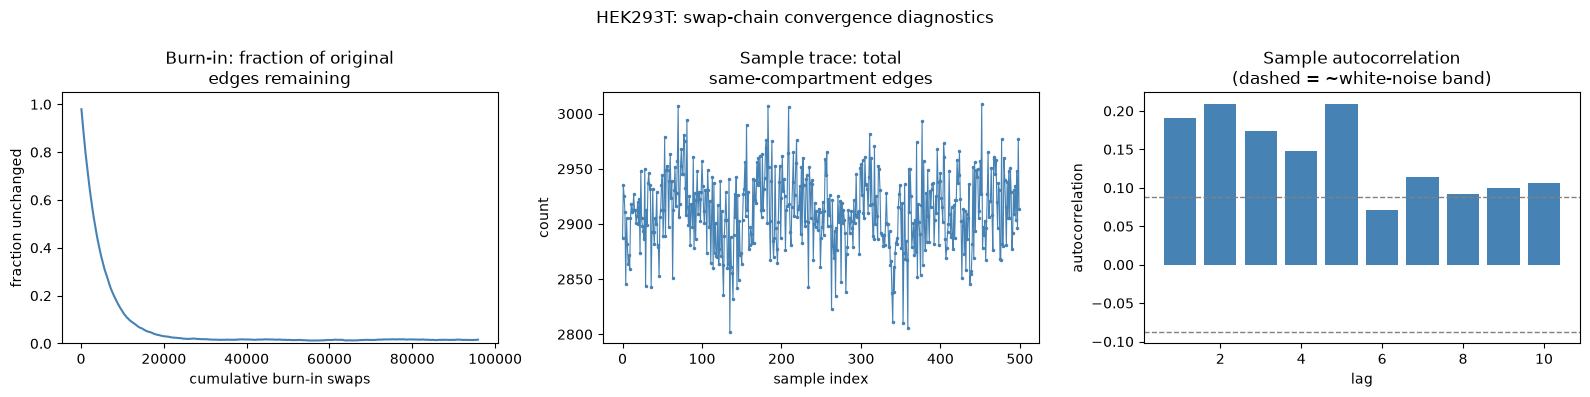

In [48]:
def plot_swap_diagnostics(null_dist: pd.DataFrame, diagnostics: dict, title_prefix: str):
    """Plot convergence diagnostics for a double-edge-swap null distribution and print a
    plain-language completion/warning summary.

    See section 2.3b for what each of the three panels means and why. All three are derived
    from data already produced by build_null_distribution -- no extra swaps are run here.

    Parameters:
        null_dist (pd.DataFrame): null distribution as returned by build_null_distribution.
        diagnostics (dict): diagnostics dict as returned by build_null_distribution, with
            "burn_in" and "samples" keys.
        title_prefix (str): label (e.g. a cell line name) used in the figure title and the
            printed summary.

    Returns:
        (matplotlib.figure.Figure): the assembled 3-panel figure.
    """
    burn_in = diagnostics["burn_in"]
    sample_diag = diagnostics["samples"]

    same_compartment_cols = [c for c in null_dist.columns if c[0] == c[1]]
    trace = null_dist[same_compartment_cols].sum(axis=1)

    n_lags = 10
    autocorr = [trace.autocorr(lag=k) for k in range(1, n_lags + 1)]
    band = 1.96 / np.sqrt(len(trace))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    if burn_in["overlap_trace"]:
        xs, ys = zip(*burn_in["overlap_trace"])
        axes[0].plot(xs, ys, color="steelblue")
    axes[0].set_title("Burn-in: fraction of original\nedges remaining")
    axes[0].set_xlabel("cumulative burn-in swaps")
    axes[0].set_ylabel("fraction unchanged")
    axes[0].set_ylim(0, 1.05)

    axes[1].plot(trace.values, color="steelblue", marker=".", linewidth=0.8, markersize=3)
    axes[1].set_title("Sample trace: total\nsame-compartment edges")
    axes[1].set_xlabel("sample index")
    axes[1].set_ylabel("count")

    axes[2].bar(range(1, n_lags + 1), autocorr, color="steelblue")
    axes[2].axhline(band, color="grey", linestyle="--", linewidth=1)
    axes[2].axhline(-band, color="grey", linestyle="--", linewidth=1)
    axes[2].set_title("Sample autocorrelation\n(dashed = ~white-noise band)")
    axes[2].set_xlabel("lag")
    axes[2].set_ylabel("autocorrelation")

    fig.suptitle(f"{title_prefix}: swap-chain convergence diagnostics")
    plt.tight_layout()

    burn_in_pct = 100 * burn_in["done"] / burn_in["target"]
    sample_done = sum(d["done"] for d in sample_diag)
    sample_target = sum(d["target"] for d in sample_diag)
    sample_pct = 100 * sample_done / sample_target
    sample_failed_batches = sum(d["n_batches_failed"] for d in sample_diag)

    print(f"{title_prefix} burn-in: {burn_in['done']:,}/{burn_in['target']:,} swaps completed "
          f"({burn_in_pct:.1f}%), {burn_in['n_batches_failed']} batch(es) hit NetworkXAlgorithmError")
    print(f"{title_prefix} sampling: {sample_done:,}/{sample_target:,} swaps completed "
          f"({sample_pct:.1f}%) across {len(sample_diag)} inter-sample gaps, "
          f"{sample_failed_batches} batch(es) hit NetworkXAlgorithmError")
    print(f"{title_prefix} lag-1 autocorrelation of same-compartment-edge trace: {autocorr[0]:.3f} "
          f"(white-noise band: +-{band:.3f})")
    if burn_in_pct < 99:
        print(f"  WARNING: burn-in undershot its target by {100 - burn_in_pct:.1f}% -- the null "
              "may still carry some of the real graph's structure. Consider a larger BURN_IN_MULTIPLIER.")
    if abs(autocorr[0]) > band:
        print("  WARNING: lag-1 autocorrelation exceeds the white-noise band -- consider a larger "
              "SWAPS_PER_SAMPLE_MULTIPLIER.")

    return fig


fig = plot_swap_diagnostics(null_dist_hek293t, diag_hek293t, "HEK293T")
plt.savefig(OUTPUT_DIR / "swap_diagnostics_hek293t.png", dpi=150)
plt.show()

## 2.4 Per-pair significance: z-scores and FDR-corrected empirical p-values

For each compartment pair, compare the single observed count against its ~500-sample null
distribution: a z-score (parametric summary of how far out it sits) and an **empirical**, two-sided
p-value (the honest, distribution-free version -- what fraction of null samples were at least as
extreme as the real value, in either direction). Because we're testing every compartment pair
simultaneously, we apply Benjamini-Hochberg FDR correction across all of them rather than trusting
raw p-values one at a time.

In [49]:
def benjamini_hochberg(pvals: np.ndarray) -> np.ndarray:
    """Compute Benjamini-Hochberg FDR-adjusted q-values for an array of raw p-values.

    Parameters:
        pvals (np.ndarray): raw, unadjusted p-values for a set of simultaneous hypothesis
            tests.

    Returns:
        (np.ndarray): BH-adjusted q-values, same length and order as `pvals`.
    """
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]  # enforce monotonicity
    q_full = np.empty(n)
    q_full[order] = np.clip(q, 0, 1)
    return q_full


def score_mixing_matrix(obs_counts: pd.Series, null_dist: pd.DataFrame) -> pd.DataFrame:
    """Score each compartment pair's observed mixing count against its null distribution.

    Computes a z-score, an empirical two-sided p-value, and a BH-corrected q-value for every
    compartment pair.

    Parameters:
        obs_counts (pd.Series): observed edge counts indexed by canonical compartment-pair
            tuples, as returned by compute_mixing_counts.
        null_dist (pd.DataFrame): null distribution of mixing counts, one row per null
            sample and one column per canonical compartment pair, as returned by
            build_null_distribution.

    Returns:
        (pd.DataFrame): one row per compartment pair, with columns compartment_a,
            compartment_b, observed, null_mean, null_std, z_score, p_empirical, q_value,
            direction ("enriched"/"depleted"), and significant (q_value < 0.05); sorted by
            q_value.
    """
    rows = []
    for pair in null_dist.columns:
        observed = obs_counts.get(pair, 0)
        null_vals = null_dist[pair].values
        mean_null, std_null = null_vals.mean(), null_vals.std()
        z = (observed - mean_null) / std_null if std_null > 0 else np.nan

        # Continuity-corrected empirical p-value (Davison & Hinkley convention): counting
        # the observed value itself as one more sample avoids a p-value of exactly 0, which
        # would otherwise happen whenever the real count falls outside the entire null sample
        # range -- a real possibility with only N_NULL_SAMPLES draws, and a value that breaks
        # BH-FDR ranking (ties at exactly 0 sort arbitrarily) and overstates certainty.
        frac_ge = (np.sum(null_vals >= observed) + 1) / (len(null_vals) + 1)  # enrichment evidence
        frac_le = (np.sum(null_vals <= observed) + 1) / (len(null_vals) + 1)  # depletion evidence
        p_empirical = min(1.0, 2 * min(frac_ge, frac_le))

        rows.append({
            "compartment_a": pair[0], "compartment_b": pair[1],
            "observed": observed, "null_mean": mean_null, "null_std": std_null,
            "z_score": z, "p_empirical": p_empirical,
        })
    result = pd.DataFrame(rows)
    result["q_value"] = benjamini_hochberg(result["p_empirical"].values)
    result["direction"] = np.where(result["z_score"] > 0, "enriched", "depleted")
    result["significant"] = result["q_value"] < 0.05
    return result.sort_values("q_value")


scores_hek293t = score_mixing_matrix(obs_counts_hek293t, null_dist_hek293t)
print(f"{scores_hek293t['significant'].sum()}" + " / " + f"{len(scores_hek293t)} compartment pairs "
      f"significant at FDR < 0.05")
scores_hek293t.head(15)

27 / 78 compartment pairs significant at FDR < 0.05


,compartment_a,compartment_b,observed,null_mean,null_std,z_score,p_empirical,q_value,direction,significant
12,cytoskeleton,cytoskeleton,9,1.230,0.945040,8.221877,0.003992,0.012455,enriched,True
28,cytosol,mitochondrion,109,209.458,12.233407,-8.211776,0.003992,0.012455,depleted,True
23,cytosol,cytosol,90,31.224,4.897124,12.002146,0.003992,0.012455,enriched,True
18,cytoskeleton,mitochondrion,8,38.722,5.616468,-5.469985,0.003992,0.012455,depleted,True
29,cytosol,nucleus,475,535.004,15.977859,-3.755447,0.003992,0.012455,depleted,True
59,lysosome,nucleus,12,25.378,3.739400,-3.577579,0.003992,0.012455,depleted,True
63,mitochondrion,mitochondrion,1121,345.538,15.221845,50.944023,0.003992,0.012455,enriched,True
52,golgi,mitochondrion,39,97.732,8.094948,-7.255390,0.003992,0.012455,depleted,True
43,extracellular,golgi,113,27.660,4.979598,17.137928,0.003992,0.012455,enriched,True
42,extracellular,extracellular,113,32.476,5.475530,14.706157,0.003992,0.012455,enriched,True


### A note on the Gaussian assumption

`z_score` above is a Gaussian-flavored summary ("how many standard deviations from the null
mean") -- useful as an at-a-glance effect size, but only literally means what it implies if the
null distribution is roughly normal. **The actual significance call (`q_value`, `significant`)
does not depend on this** -- `p_empirical` is computed by directly counting how many of the
`N_NULL_SAMPLES` shuffled graphs were at least as extreme as the real one, which needs no
distributional assumption at all.

Whether normality is even reasonable varies a lot cell by cell: large, common compartment pairs
(nucleus-nucleus, cytosol-cytosol) involve sums over many potential edges and tend toward
Gaussian-ish by the Central Limit Theorem. Small/rare compartment pairs (e.g. anything involving
peroxisome) often have a null expectation near zero -- discrete, right-skewed, piled up at zero --
which is nothing like a bell curve (and can even have zero variance, making `z_score` undefined --
see the `std_null > 0 else np.nan` guard above). Since those rare pairs are often exactly where
the interesting biology lives, this isn't a corner case worth ignoring. The cell below plots the
real null histograms for one common and one rare pair so you can see the difference directly,
rather than taking that claim on faith.

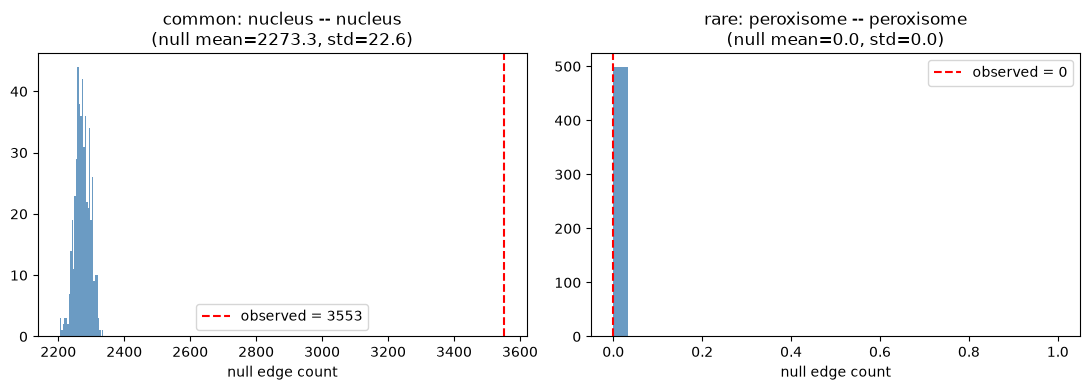

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pair_totals = {pair: null_dist_hek293t[pair].sum() for pair in null_dist_hek293t.columns}
common_pair = max(pair_totals, key=pair_totals.get)
rare_pair = min(pair_totals, key=pair_totals.get)

for ax, pair, label in [(axes[0], common_pair, "common"), (axes[1], rare_pair, "rare")]:
    vals = null_dist_hek293t[pair]
    ax.hist(vals, bins=30, color="steelblue", alpha=0.8)
    obs = obs_counts_hek293t.get(pair, 0)
    ax.axvline(obs, color="red", linestyle="--", label=f"observed = {obs}")
    ax.set_title(f"{label}: {pair[0]} -- {pair[1]}\n(null mean={vals.mean():.1f}, std={vals.std():.1f})")
    ax.set_xlabel("null edge count")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "null_distribution_shape_qc.png", dpi=150)
plt.show()


## 2.5 Visualization: enrichment/depletion heatmap

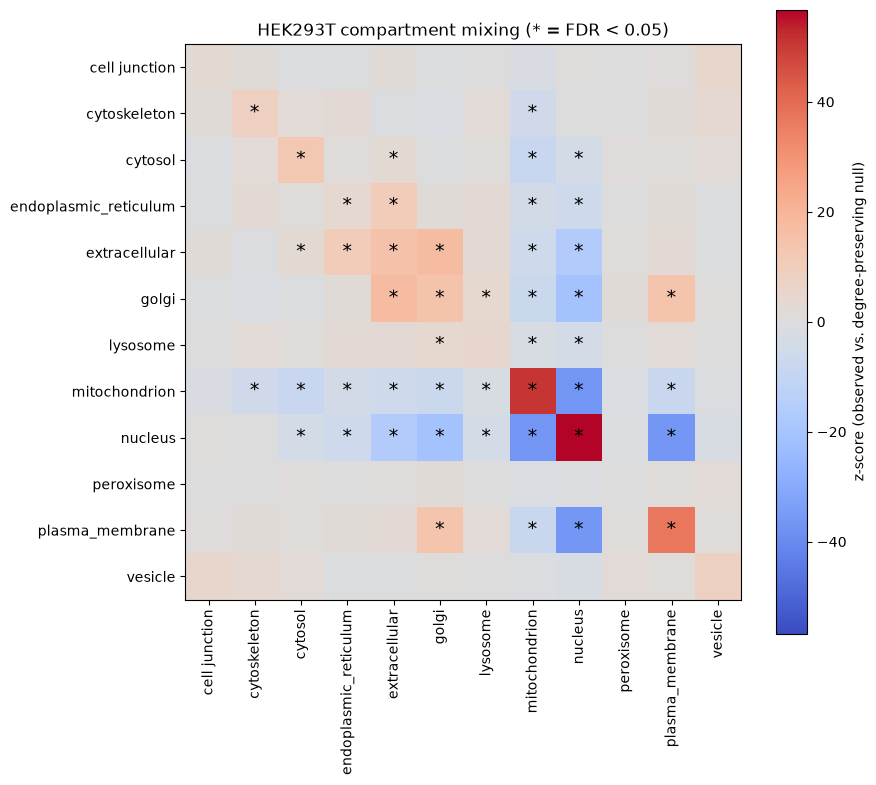

In [51]:
def plot_mixing_heatmap(scores: pd.DataFrame, compartments: list, title: str, ax=None):
    """Draw a compartment x compartment z-score heatmap, marking FDR-significant pairs with
    an asterisk.

    Parameters:
        scores (pd.DataFrame): per-pair scores as returned by score_mixing_matrix, with
            compartment_a, compartment_b, z_score, and significant columns.
        compartments (list): full list of compartment names to use as the heatmap's
            row/column order.
        title (str): title to display above the heatmap.
        ax (matplotlib.axes.Axes | None): axes to draw on. If None, a new figure and axes
            are created. Defaults to None.

    Returns:
        (matplotlib.axes.Axes): the axes the heatmap was drawn on.
    """
    z_matrix = pd.DataFrame(np.nan, index=compartments, columns=compartments)
    sig_matrix = pd.DataFrame(False, index=compartments, columns=compartments)
    for _, row in scores.iterrows():
        a, b, z, sig = row["compartment_a"], row["compartment_b"], row["z_score"], row["significant"]
        z_matrix.loc[a, b] = z_matrix.loc[b, a] = z
        sig_matrix.loc[a, b] = sig_matrix.loc[b, a] = sig

    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
    vmax = np.nanmax(np.abs(z_matrix.values))
    im = ax.imshow(z_matrix.values, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(compartments))); ax.set_xticklabels(compartments, rotation=90)
    ax.set_yticks(range(len(compartments))); ax.set_yticklabels(compartments)
    ax.set_title(title)

    for i, a in enumerate(compartments):
        for j, b in enumerate(compartments):
            if sig_matrix.loc[a, b]:
                ax.text(j, i, "*", ha="center", va="center", color="black", fontsize=14)

    plt.colorbar(im, ax=ax, label="z-score (observed vs. degree-preserving null)")
    return ax

fig, ax = plt.subplots(figsize=(9, 8))
plot_mixing_heatmap(scores_hek293t, compartments_list, "HEK293T compartment mixing (* = FDR < 0.05)", ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mixing_heatmap_hek293t.png", dpi=150)
plt.show()

## 2.6 Global summary: mutual information

The per-pair z-scores answer "is *this* pair enriched or depleted." This section adds one number
answering "how non-random is the *entire* mixing structure" -- useful as a single headline stat,
and directly reusable in Stage 4 (Jensen-Shannon divergence between HEK293T's and HCT116's overall
organization is built from the same object).

**This is where the counting convention changes.** We now build the properly normalized,
Newman-style symmetric joint distribution `e_ij`, where the full matrix sums to 1: diagonal cells
get `count / M`, and each off-diagonal pair of symmetric cells gets `count / (2M)` apiece (a
cross-compartment edge's probability mass is split evenly between its two symmetric matrix
entries; a same-compartment edge's mass all lands on one diagonal cell). This convention matters
here specifically because mutual information is defined over a normalized joint distribution.

Mutual information is then the KL divergence between that observed joint distribution and the
"independence" distribution built from its own marginals (`a_i` = total probability mass touching
compartment i) -- i.e., how much better the real joint distribution predicts an edge's endpoints
than assuming compartments interact independently, in proportion to their overall abundance.

In [52]:
def build_e_matrix(obs_counts: pd.Series, compartments: list) -> pd.DataFrame:
    """Build the normalized, symmetric joint probability distribution `e_ij` over
    compartment pairs (Newman-style mixing matrix), where the full matrix sums to 1.

    Parameters:
        obs_counts (pd.Series): observed edge counts indexed by canonical
            compartment-pair tuples, as returned by compute_mixing_counts.
        compartments (list): full list of compartment names to use as the matrix's
            row/column index.

    Returns:
        (pd.DataFrame): symmetric compartment x compartment DataFrame of joint edge
            probabilities; diagonal cells hold count / M, off-diagonal pairs split
            count / (2M) evenly across their two symmetric entries, where M is the total
            edge count.
    """
    M = obs_counts.sum()
    e = pd.DataFrame(0.0, index=compartments, columns=compartments)
    for (a, b), count in obs_counts.items():
        if a == b:
            e.loc[a, b] = count / M
        else:
            e.loc[a, b] = e.loc[b, a] = count / (2 * M)
    return e


def mutual_information_bits(e_matrix: pd.DataFrame) -> float:
    """Compute the mutual information (in bits) between a compartment-mixing joint
    distribution and the "independence" distribution implied by its own marginals -- a
    single summary statistic for how non-random the overall mixing structure is.

    Parameters:
        e_matrix (pd.DataFrame): normalized, symmetric joint probability distribution over
            compartment pairs, as returned by build_e_matrix.

    Returns:
        (float): mutual information in bits; 0 if compartment identity is uninformative
            about interaction partners, higher values indicate compartment identity
            predicts connection pattern more strongly.
    """
    a = e_matrix.sum(axis=1)  # marginals
    mi = 0.0
    for i in e_matrix.index:
        for j in e_matrix.columns:
            eij = e_matrix.loc[i, j]
            if eij > 0:
                mi += eij * np.log2(eij / (a[i] * a[j]))
    return mi


e_matrix_hek293t = build_e_matrix(obs_counts_hek293t, compartments_list)
mi_hek293t = mutual_information_bits(e_matrix_hek293t)
print(f"HEK293T compartment mixing mutual information: {mi_hek293t:.4f} bits")
print("(0 = compartment identity is uninformative about interaction partners; "
      "higher = compartment identity predicts connection pattern more strongly)")

HEK293T compartment mixing mutual information: 0.3910 bits
(0 = compartment identity is uninformative about interaction partners; higher = compartment identity predicts connection pattern more strongly)


## 2.7 Run the full pipeline on HCT116, and save everything

Same functions, same parameters, applied to `G_hct116_sub` -- this is the point of having built
each step as a reusable function rather than one-off script code. We are *not* yet comparing the
two cell lines statistically here (that's Stage 4) -- we're just producing matched, independently
computed outputs for each, ready to be compared.

[HCT116] burn-in done (9s) -- starting 500 samples
[HCT116] sample 25/500 (5%) -- elapsed 0m, ETA 4m
[HCT116] sample 50/500 (10%) -- elapsed 0m, ETA 5m
[HCT116] sample 75/500 (15%) -- elapsed 0m, ETA 4m
[HCT116] sample 100/500 (20%) -- elapsed 1m, ETA 4m
[HCT116] sample 125/500 (25%) -- elapsed 1m, ETA 3m
[HCT116] sample 150/500 (30%) -- elapsed 1m, ETA 3m
[HCT116] sample 175/500 (35%) -- elapsed 1m, ETA 3m
[HCT116] sample 200/500 (40%) -- elapsed 1m, ETA 2m
[HCT116] sample 225/500 (45%) -- elapsed 2m, ETA 2m
[HCT116] sample 250/500 (50%) -- elapsed 2m, ETA 2m
[HCT116] sample 275/500 (55%) -- elapsed 2m, ETA 2m
[HCT116] sample 300/500 (60%) -- elapsed 2m, ETA 1m
[HCT116] sample 325/500 (65%) -- elapsed 3m, ETA 1m
[HCT116] sample 350/500 (70%) -- elapsed 3m, ETA 1m
[HCT116] sample 375/500 (75%) -- elapsed 3m, ETA 1m
[HCT116] sample 400/500 (80%) -- elapsed 3m, ETA 0m
[HCT116] sample 425/500 (85%) -- elapsed 4m, ETA 0m
[HCT116] sample 450/500 (90%) -- elapsed 4m, ETA 0m
[HCT116] sample 4

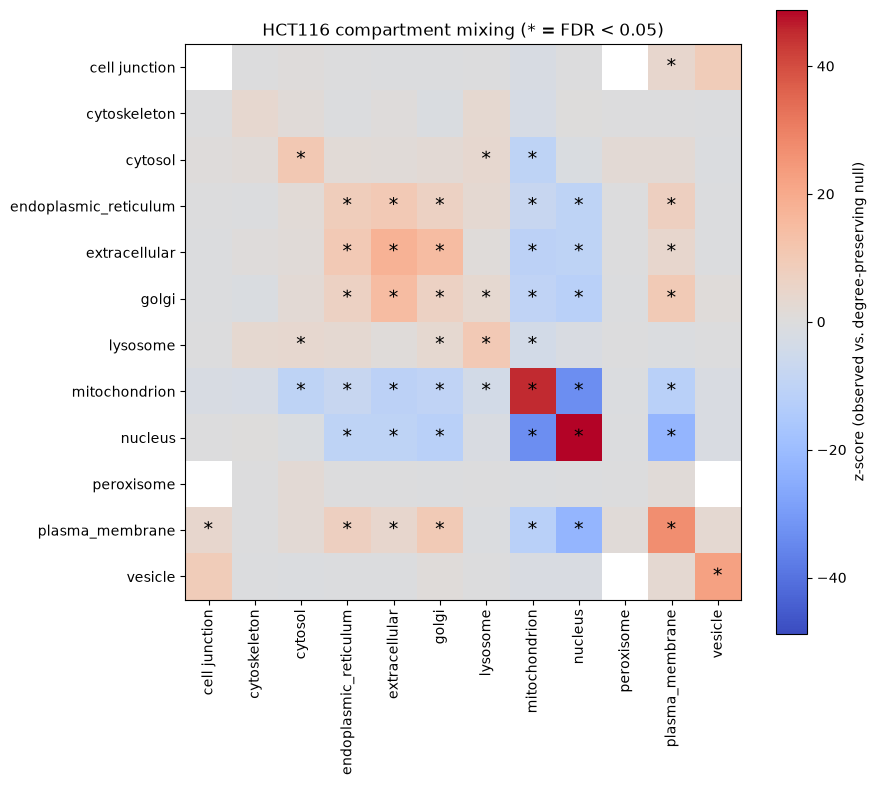

HCT116 burn-in: 57,750/57,750 swaps completed (100.0%), 0 batch(es) hit NetworkXAlgorithmError
HCT116 sampling: 5,775,000/5,775,000 swaps completed (100.0%) across 500 inter-sample gaps, 0 batch(es) hit NetworkXAlgorithmError
HCT116 lag-1 autocorrelation of same-compartment-edge trace: 0.469 (white-noise band: +-0.088)


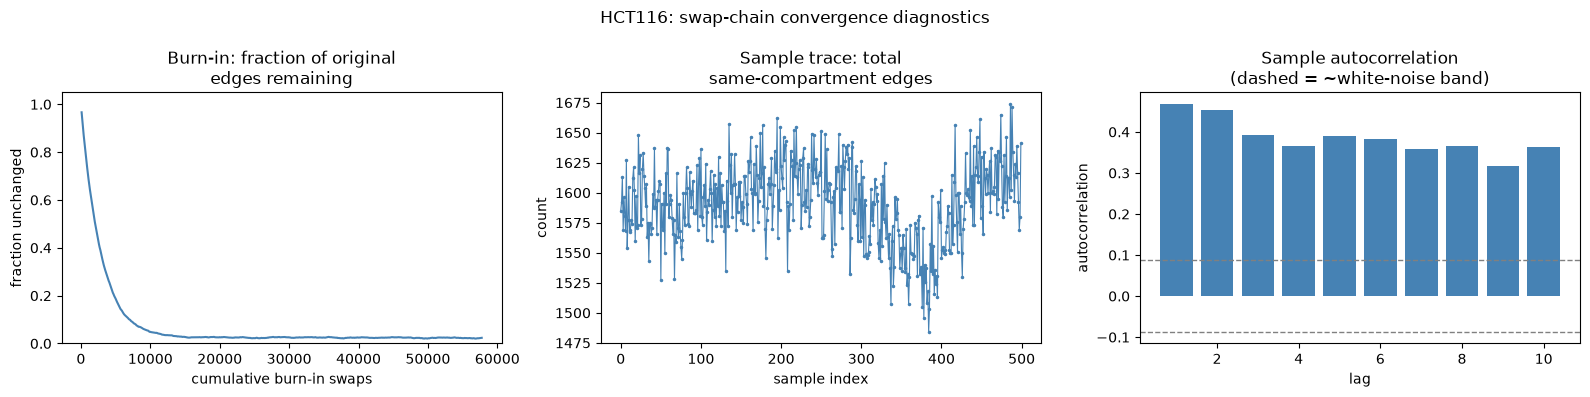

In [53]:
obs_counts_hct116 = compute_mixing_counts(G_hct116_sub)
obs_matrix_hct116 = mixing_counts_to_matrix(obs_counts_hct116, compartments_list)

null_dist_hct116, diag_hct116 = build_null_distribution(G_hct116_sub, compartments_list,
                                                         seed=RNG_SEED + 1, label="HCT116")
scores_hct116 = score_mixing_matrix(obs_counts_hct116, null_dist_hct116)

e_matrix_hct116 = build_e_matrix(obs_counts_hct116, compartments_list)
mi_hct116 = mutual_information_bits(e_matrix_hct116)

print(f"HCT116: {obs_counts_hct116.sum():,} edges used, "
      f"{scores_hct116['significant'].sum()} / {len(scores_hct116)} pairs significant at FDR < 0.05, "
      f"MI = {mi_hct116:.4f} bits")

fig, ax = plt.subplots(figsize=(9, 8))
plot_mixing_heatmap(scores_hct116, compartments_list, "HCT116 compartment mixing (* = FDR < 0.05)", ax=ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mixing_heatmap_hct116.png", dpi=150)
plt.show()

fig = plot_swap_diagnostics(null_dist_hct116, diag_hct116, "HCT116")
plt.savefig(OUTPUT_DIR / "swap_diagnostics_hct116.png", dpi=150)
plt.show()

In [54]:
# Persist everything Stage 4 needs to compare the two cell lines, and everything Stage 3
# needs as background (compartments_list, e.g.).
obs_matrix_hek293t.to_csv(OUTPUT_DIR / "mixing_matrix_hek293t.csv")
obs_matrix_hct116.to_csv(OUTPUT_DIR / "mixing_matrix_hct116.csv")

scores_hek293t.to_csv(OUTPUT_DIR / "mixing_zscores_hek293t.csv", index=False)
scores_hct116.to_csv(OUTPUT_DIR / "mixing_zscores_hct116.csv", index=False)

with open(OUTPUT_DIR / "mixing_summary_hek293t.json", "w") as f:
    json.dump({"total_edges": int(obs_counts_hek293t.sum()), "mutual_information_bits": mi_hek293t,
               "n_significant_pairs": int(scores_hek293t["significant"].sum())}, f, indent=2)

with open(OUTPUT_DIR / "mixing_summary_hct116.json", "w") as f:
    json.dump({"total_edges": int(obs_counts_hct116.sum()), "mutual_information_bits": mi_hct116,
               "n_significant_pairs": int(scores_hct116["significant"].sum())}, f, indent=2)

print("Saved mixing matrices, z-score tables, and summary stats for both cell lines to ./data/stage2")

Saved mixing matrices, z-score tables, and summary stats for both cell lines to ./data/stage2


## Recap and what's next

For each cell line, `./data/stage2` now has: the raw observed mixing matrix, a full per-pair z-score /
FDR table, a heatmap PNG, a swap-chain diagnostics PNG, and a one-number mutual-information summary.

**Worth inspecting by hand before Stage 3:**
- Which specific compartment pairs came out significantly *enriched* -- do any look like known
  biology (e.g. ER-mitochondria contact sites) as a sanity check?
- Section 2.3b's printed summary and plots for both cell lines -- confirm burn-in completed close
  to 100% of its target (overlap-trace plateaued) and that the lag-1 autocorrelation of the sample
  trace sits inside the printed white-noise band. If either warning fires, rerun with a larger
  `BURN_IN_MULTIPLIER` or `SWAPS_PER_SAMPLE_MULTIPLIER` respectively -- `null_std` is otherwise
  underestimated, which makes z-scores and q-values slightly too liberal.

**Stage 3, next:** using the *same* induced subgraphs built here, plus the multi-compartment
proteins we set aside back in Stage 1, compute the participation coefficient for every protein and
identify candidate mediator/bridge proteins -- validating against known membrane-contact-site
tethers before trusting anything novel.

In [55]:
# scores_hct116.head()
for i, row in enumerate(scores_hct116.iterrows()):
    series = row[1]

    if (series["compartment_a"] == "peroxisome"
        and series["compartment_b"] == "peroxisome"):
        print(series)
        

compartment_a    peroxisome
compartment_b    peroxisome
observed                  0
null_mean             0.002
null_std           0.044677
z_score           -0.044766
p_empirical             1.0
q_value                 1.0
direction          depleted
significant           False
Name: 72, dtype: object
